In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data_science_job.csv')
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
4900,6553,city_115,0.789,NaN,No relevent experience,no_enrollment,Masters,STEM,10.0,50-99,Pvt Ltd,79.0,0.0
18863,10381,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,Humanities,19.0,10000+,Pvt Ltd,13.0,1.0
12209,2952,city_103,0.920,Male,Has relevent experience,Full time course,Graduate,STEM,5.0,5000-9999,Public Sector,111.0,0.0
12591,1105,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,20.0,100-500,Pvt Ltd,34.0,0.0
16597,13801,city_16,0.910,Male,Has relevent experience,no_enrollment,Graduate,STEM,15.0,10000+,Pvt Ltd,100.0,0.0


In [4]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [6]:
#Apply CCA in that column in which total missing data will be less than 5%

In [7]:
#finding out that columns:
eligible_col =[]
for col in df.columns:
    if ((df[col].isnull().mean() *100 )<5 and (df[col].isnull().mean()*100 > 0)):
        eligible_col.append(col)
eligible_col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df[eligible_col].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
16981,0.926,no_enrollment,Masters,4.0,53.0
12157,0.739,Full time course,Graduate,4.0,69.0
11494,0.624,no_enrollment,Graduate,15.0,103.0
12855,0.878,no_enrollment,Phd,20.0,8.0
8771,0.926,no_enrollment,Masters,2.0,30.0


In [9]:
len(df[eligible_col].dropna())/len(df)

0.8968577095730244

In [10]:
new_df = df[eligible_col].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

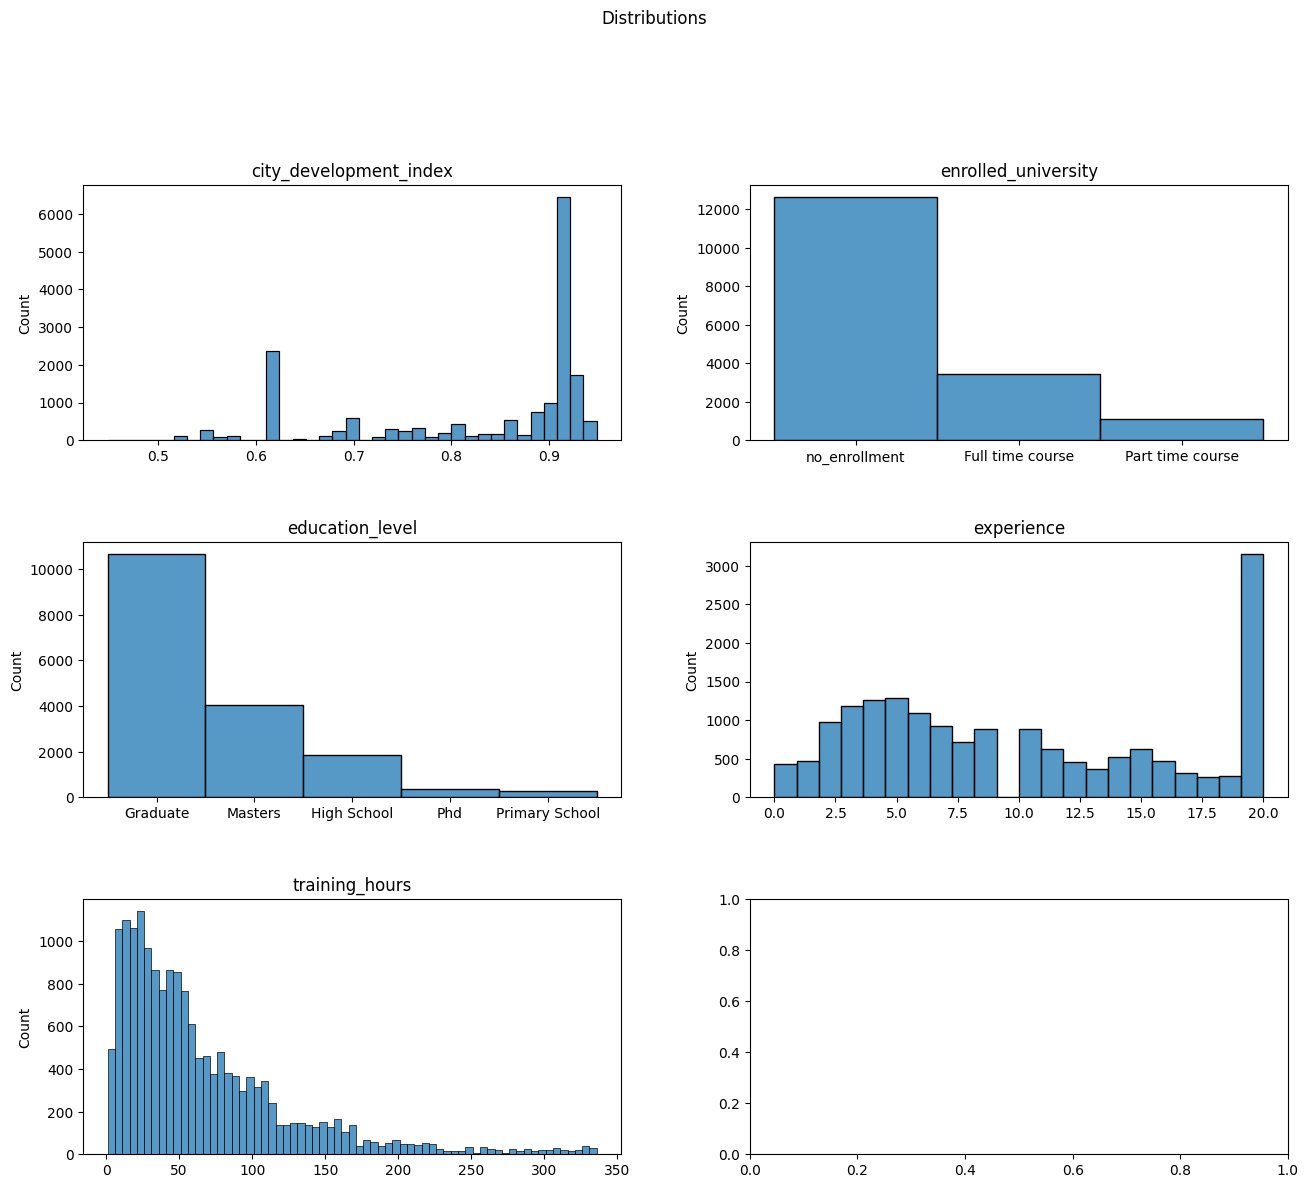

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(new_df.columns):
    sns.histplot(new_df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('') 

fig.suptitle('Distributions', y=1.02)  
plt.tight_layout(pad=4.0)
plt.show()

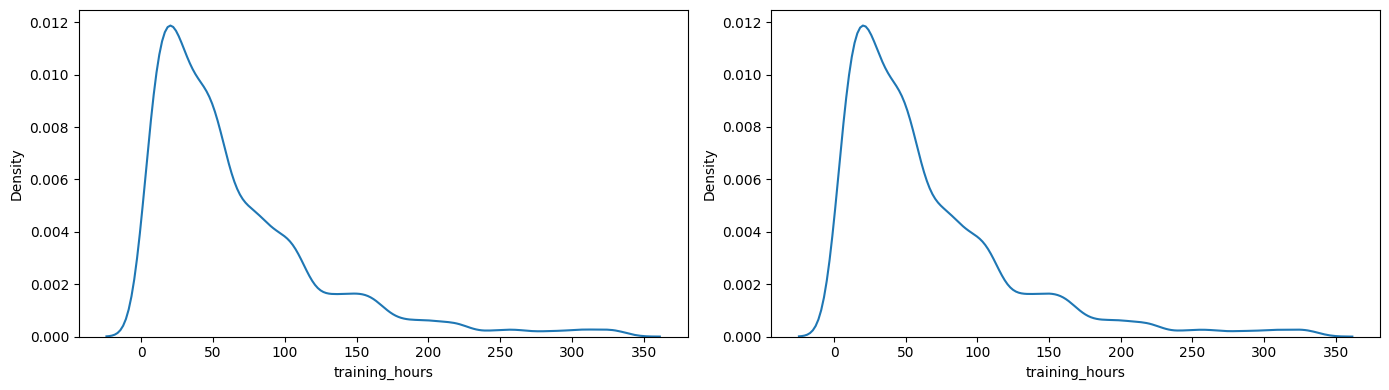

In [18]:
#checking distribution by KDE plot
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.kdeplot(df.training_hours)

plt.subplot(1,2,2)
sns.kdeplot(new_df['training_hours'])
plt.tight_layout()
plt.show()

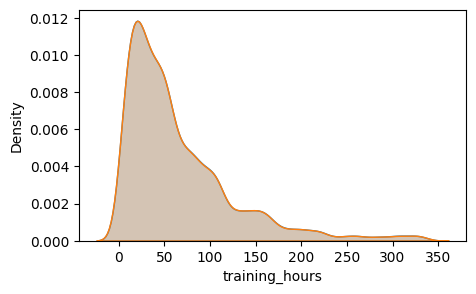

In [28]:
plt.figure(figsize=(5,3))
sns.kdeplot(df['training_hours'], fill=True)
sns.kdeplot(new_df['training_hours'], fill =True)
plt.show()

# here, we can know that two curves are overlapped with each other and their distribution are same,
#therefore, it is better for CCA

#### CCA in Categorical Column

In [ ]:
#same ratio should be maintained before CCA and after CCA.

In [29]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64